In [1]:
from dlfs.base import Module, Loss, Optimizer, Layer

from dlfs.modules import SequentialWrapper
from dlfs.layers import DenseLayer, ConvLayer, ConvTransposeLayer, BatchNorm2D
from dlfs.activation import SiLU

from dlfs.loss import MSE_Loss
from dlfs.optimizers import Optimizer_Adam, Optimizer_AdamW
from dlfs.helpers import get_random_batch, DLFSData

import numpy as np
import matplotlib.pyplot as plt

# U-Net block for upsamplig/downsampling

In [2]:
class Block(Module):

    def __init__(self, input_channels: int, output_channels: int, time_emb_dim: int, up: bool = False):

        self.time_mlp = DenseLayer(time_emb_dim, output_channels)

        if up:
            self.conv1 = ConvLayer(2*input_channels, output_channels, kernel_size=3, padding=1)
            self.transform = ConvTransposeLayer(output_channels, output_channels, kernel_size=4, stride=2, padding=1)
        else:
            self.conv1 = ConvLayer(input_channels, output_channels, kernel_size=3, padding=1)
            self.transform = ConvLayer(output_channels, output_channels, kernel_size=4, stride=2, padding=1)

        self.conv2 = ConvLayer(input_channels=output_channels, 
                               output_channels=output_channels, 
                               kernel_size=3, 
                               stride=1, 
                               padding=1)

        self.bnorm1 = BatchNorm2D(output_channels)
        self.bnorm2 = BatchNorm2D(output_channels)

        self.relu1 = SiLU()
        self.relu2 = SiLU()
        self.relu3 = SiLU()

    def forward(self, x: np.ndarray, t: np.ndarray, training: bool = False):

        self.conv1.forward(x)
        self.relu1.forward(self.conv1.output)
        self.bnorm1.forward(self.relu1.output)

        h = self.bnorm1.output.copy()

        self.time_mlp.forward(t)
        self.relu2.forward(self.time_mlp.output)

        time_emb = self.relu2.output[(..., ) + (None, ) * 2].copy()

        new = h + time_emb

        self.conv2.forward(new)
        self.relu3.forward(self.conv2.output)
        self.bnorm2.forward(self.relu3.output)

        self.transform.forward(self.bnorm2.output)

        self.output = self.transform.output

    def backward(self, delta: np.ndarray):

        self.transform.backward(delta)

        self.bnorm2.backward(self.transform.dinputs)
        self.relu3.backward(self.bnorm2.dinputs)
        self.conv2.backward(self.relu3.dinputs)

        dh = self.conv2.dinputs.copy()
        dtime_emb = self.conv2.dinputs.copy()

        dtime_emb = np.sum(dtime_emb, axis=(2,3))

        self.relu2.backward(dtime_emb)
        self.time_mlp.backward(self.relu2.dinputs)
        self.dt = self.time_mlp.dinputs

        self.bnorm1.backward(dh)
        self.relu1.backward(self.bnorm1.dinputs)
        self.conv1.backward(self.relu1.dinputs)

        self.dinputs = self.conv1.dinputs

# U-Net

In [3]:
class UNet(Module):

    def __init__(self, input_channels: int = 1, output_channels: int = 1, time_emb_dim: int = 32, down_channels: tuple = (16,32,64)):
        self.time_emb_dim = time_emb_dim

        up_channels = tuple(reversed(down_channels))

        self.conv0 = ConvLayer(input_channels, down_channels[0], kernel_size=3, stride=1, padding=1)

        self.downs = [
            Block(down_channels[i], down_channels[i + 1], time_emb_dim=time_emb_dim) for i in range(len(down_channels) - 1) 
        ]

        self.bottleneck = SequentialWrapper(
            [ConvLayer(down_channels[-1], down_channels[-1], kernel_size=1, stride=1, padding=0),
             SiLU(),
             ConvLayer(down_channels[-1], down_channels[-1], kernel_size=1, stride=1, padding=0),
             SiLU()]
        )

        self.ups = [
            Block(up_channels[i], up_channels[i + 1], time_emb_dim=time_emb_dim, up=True) for i in range(len(up_channels) - 1) 
        ]

        self.conv_last = ConvLayer(up_channels[-1], output_channels, kernel_size=1, stride=1, padding=0)

        self.time_mlp = SequentialWrapper(
            [DenseLayer(time_emb_dim, time_emb_dim),
             SiLU()]
        )

    def timestep_embedding(self, t: np.ndarray, dim: int):
        t = np.asarray(t).reshape(-1, 1)
        half_dim = dim // 2

        i = np.arange(half_dim, dtype=np.float32)
        freqs = np.exp(-np.log(10000) * (2 * i / dim))  # stable version
        args = t * freqs

        return np.concatenate([np.sin(args), np.cos(args)], axis=-1)

    def forward(self, x: np.ndarray, t: np.ndarray, training: bool = False):

        t_emb = self.timestep_embedding(t, self.time_emb_dim)
        self.time_mlp.forward(t_emb)
        t_emb = self.time_mlp.output

        self.conv0.forward(x)
        x_down = self.conv0.output

        self.residual_inputs = []

        for d in self.downs:
            d.forward(x_down, t_emb)
            self.residual_inputs.append(d.output.copy())
            x_down = d.output.copy()

        self.bottleneck.forward(self.downs[-1].output)

        x_up = self.bottleneck.output
        for idx, u in enumerate(self.ups):
            res_x = self.residual_inputs[-1-idx]
            #print(f'xup: {x_up.shape}, res_x: {res_x.shape}')
            combined = np.concatenate((x_up, res_x), axis=1)
            u.forward(combined, t_emb)
            x_up = u.output.copy()

        self.conv_last.forward(self.ups[-1].output)

        self.output = self.conv_last.output

    def backward(self, delta: np.ndarray):

        self.conv_last.backward(delta)
        grad = self.conv_last.dinputs      # gradient for last up block

        d_t_emb_total = np.zeros_like(self.time_mlp.output)

        residual_stack = list(reversed(self.residual_inputs))

        for u in reversed(self.ups):
            u.backward(grad)

            B, C, H, W = u.dinputs.shape

            skip = residual_stack.pop()
            skip_c = skip.shape[1]
            main_c = u.dinputs.shape[1] - skip_c

            grad_main = u.dinputs[:, :main_c]
            grad_skip = u.dinputs[:, main_c:]

            grad = grad_main

            d_t_emb_total += u.dt

        self.bottleneck.backward(grad)
        grad = self.bottleneck.dinputs

        for d in reversed(self.downs):

            d.backward(grad)

            grad = d.dinputs

            d_t_emb_total += d.dt

        self.conv0.backward(grad)
        grad_x0 = self.conv0.dinputs

        self.time_mlp.backward(d_t_emb_total)
        d_t_emb = self.time_mlp.dinputs    

        self.dinputs = grad_x0
        self.dinputs_t = d_t_emb

# Diffusion model

In [4]:
class Diffusion(Module):

    def __init__(self, model: Module, 
                       image_channels: int = 1, 
                       image_size: int = 28, 
                       t_emb_dim: int = 128, 
                       timesteps=1000, 
                       loss_function: Loss = None, 
                       optimizer: Optimizer = None):

        self.model = model

        # Image properties
        self.image_channels = image_channels
        self.image_size = image_size

        # Time related properties
        self.t_emb_dim = t_emb_dim
        self.timesteps = timesteps

        # Beta scheduler, noise variances
        self.betas = np.linspace(1e-4, 0.02, timesteps)
        self.alphas = 1 - self.betas
        self.alphas_cumprod = np.cumprod(self.alphas, axis=0)
        self.ac = np.sqrt(self.alphas_cumprod)
        self.om = np.sqrt(1 - self.alphas_cumprod)

        self.loss_function = loss_function
        self.optimizer = optimizer

    def forward_diffusion(self, x0: np.ndarray, t: np.ndarray):

        ac_t = self.ac[t].reshape(-1, 1, 1, 1)
        om_t = self.om[t].reshape(-1, 1, 1, 1)

        # Sample noise of same shape as x0
        noise = np.random.randn(*x0.shape)

        # Forward diffusion formula
        x_t = ac_t * x0 + om_t * noise

        return x_t, noise

    def forward(self, x: np.ndarray, training: bool = False):

        B, C = x.shape[:2]

        t = np.random.randint(0, self.timesteps, size=(B, ))

        x_t, noise = self.forward_diffusion(x, t)

        self.model.forward(x_t, t, training=training)
        self.output = self.model.output
        self.noise_output = noise

    def backward(self, predicted: np.ndarray, noise: np.ndarray):
        self.loss_function.backward(predicted, noise)
        self.model.backward(self.loss_function.dinputs)

    def print_grads(self, layer):

        if isinstance(layer, Layer):
            params = layer.get_parameters()
            if params is None:
                return

            for name in params:
                param = getattr(layer, 'd'+name)
                print(f'{layer.__class__.__name__} grad {name}: {np.linalg.norm(param)}')

        if isinstance(layer, list):
            for l in layer:
                self.print_grads(l)

        if isinstance(layer, Module):
            for name, attr in vars(layer).items():
                self.print_grads(attr)

    def train(self, X: np.ndarray, epochs = 1000, batch_size: int = None, print_every: int = None, print_grads=False) -> None:

        # Store loss values for plotting
        self.loss_vals = []
        self.std_vals = []

        for i in range(epochs + 1):

            if batch_size is not None:
                batch_X = get_random_batch(X, batch_size=batch_size)[0]
            else:
                # If batch size is not specified take the whole dataset
                batch_X = X

            # Forward pass
            self.forward(batch_X, training=True)

            # Backward pass
            self.backward(self.output, self.noise_output)

            # Update parameters
            self.optimizer.pre_update_parameters()
            self.optimizer.update_parameters(self)
            self.optimizer.post_update_parameters()

            # Store current loss
            loss = self.loss_function.calculate(self.output, self.noise_output)
            self.loss_vals.append(loss)
            self.std_vals.append(np.std(self.output))

            if print_every is not None and not i % print_every:
                if print_grads:
                    self.print_grads(self)
                print(f'===== EPOCH : {i} ===== LOSS : {loss:.5f} ===== OUTPUT STD: {np.std(self.output):.5f} =====')

    def generate(self, n_samples: int = 10, print_every: int = 100):

        # Get batch size, number of channels, width and height of images to produce
        B, C, H, W = n_samples, self.image_channels, self.image_size, self.image_size
        
        # Start from pure Gaussian noise
        x_t = np.random.randn(B, C, H, W).astype(np.float32)

        # In reverse order start denoising
        for t in reversed(range(self.timesteps)):

            if not t % print_every:
                print(f'Generation at timestep {t}')

            # Get array of current timestep
            t_arr = np.array([t] * B)
              
            # Predict noise for current timestep
            self.model.forward(x_t, t_arr, training=False)
            epsilon_pred = self.model.output
            
            alpha_t = self.alphas[t_arr].reshape(B, 1, 1, 1)
            alpha_cumprod_t = self.alphas_cumprod[t_arr].reshape(B, 1, 1, 1)
            beta_t = self.betas[t_arr].reshape(B, 1, 1, 1)
            
            mean = (1 / np.sqrt(alpha_t)) * (x_t - ((beta_t) / np.sqrt(1 - alpha_cumprod_t)) * epsilon_pred)
            
            if t > 0:
                noise = np.random.randn(*x_t.shape)
                x_t = mean + np.sqrt(beta_t) * noise
            else:
                x_t = mean

        generated_images = x_t

        return generated_images

# Load data

In [5]:
mnist_path = "../data/mnist"

X_train, y_train, X_test, y_test = DLFSData.load_MNIST(mnist_path)

print(f'X_train: {X_train.shape}, y_train: {y_train.shape}')
print(f'X_test: {X_test.shape}, y_test: {y_test.shape}')

X_train: (60000, 28, 28), y_train: (60000,)
X_test: (10000, 28, 28), y_test: (10000,)


In [6]:
np.random.seed(1)

X_train, _ = DLFSData.select_MNIST_labels(X_train, y_train, labels=[0, 1, 2, 3], limit=500)
X_train = DLFSData.normalize_MNIST(X_train, range=(-1, 1))
X_train = np.expand_dims(X_train, axis=1)

print(f'X_train: {X_train.shape}')

X_train: (2000, 1, 28, 28)


In [7]:
lr=2e-4
epochs=1000
batch_size = 128

loss = MSE_Loss()
optimizer = Optimizer_Adam(learning_rate=lr)

unet = UNet(input_channels=1, output_channels=1, time_emb_dim=64, down_channels=(32, 64, 128)) # (32. 64. 128) min

diffusion = Diffusion(model=unet, image_channels=1, timesteps=1000, loss_function=loss, optimizer=optimizer)

diffusion.train(X_train, print_every=50, epochs=epochs, batch_size=batch_size)

===== EPOCH : 0 ===== LOSS : 0.51562 ===== OUTPUT STD: 0.15015 =====
===== EPOCH : 50 ===== LOSS : 0.14823 ===== OUTPUT STD: 0.79264 =====
===== EPOCH : 100 ===== LOSS : 0.11681 ===== OUTPUT STD: 0.86550 =====
===== EPOCH : 150 ===== LOSS : 0.07788 ===== OUTPUT STD: 0.92059 =====
===== EPOCH : 200 ===== LOSS : 0.06288 ===== OUTPUT STD: 0.93128 =====
===== EPOCH : 250 ===== LOSS : 0.05427 ===== OUTPUT STD: 0.95770 =====
===== EPOCH : 300 ===== LOSS : 0.05622 ===== OUTPUT STD: 0.91933 =====
===== EPOCH : 350 ===== LOSS : 0.04619 ===== OUTPUT STD: 0.95034 =====
===== EPOCH : 400 ===== LOSS : 0.05711 ===== OUTPUT STD: 0.95918 =====


KeyboardInterrupt: 

# Loss and STD

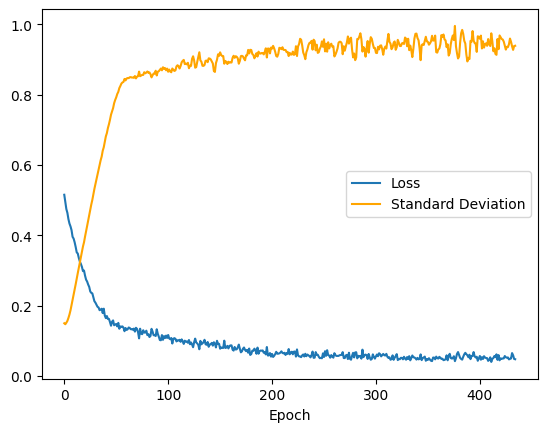

In [8]:
plt.plot(range(len(diffusion.loss_vals)), diffusion.loss_vals, label='Loss')
plt.plot(range(len(diffusion.std_vals)), diffusion.std_vals, color='orange', label='Standard Deviation')
plt.xlabel("Epoch")
plt.legend()
plt.show()

# Generating new samples

In [12]:
new_images = diffusion.generate(n_samples=25)

Generation at timestep 900
Generation at timestep 800
Generation at timestep 700
Generation at timestep 600
Generation at timestep 500
Generation at timestep 400
Generation at timestep 300
Generation at timestep 200
Generation at timestep 100
Generation at timestep 0


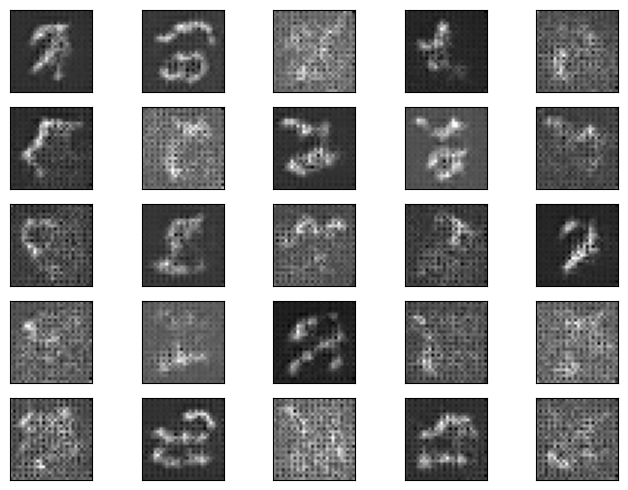

In [15]:
fig, ax = plt.subplots(nrows=5, ncols=5, figsize=(7, 5))
ax = ax.flatten()

for idx, x in enumerate(new_images):

    img = x.reshape(28, 28)

    ax[idx].imshow(img, cmap='gray')
    ax[idx].set_xticks([])
    ax[idx].set_yticks([])

plt.tight_layout()
plt.show()

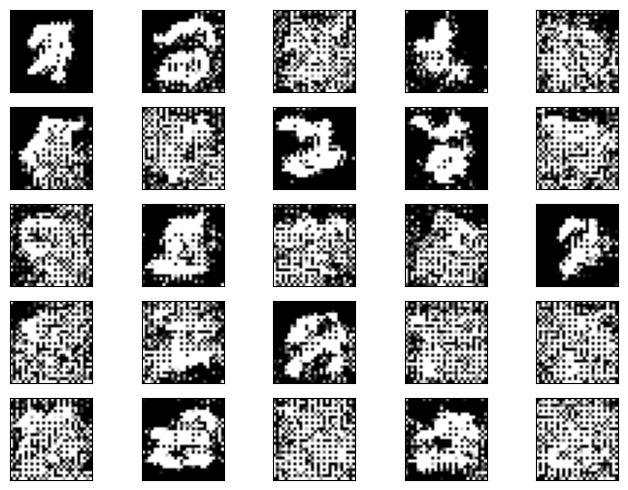

In [16]:
fig, ax = plt.subplots(nrows=5, ncols=5, figsize=(7, 5))
ax = ax.flatten()
images = DLFSData.denormalize_MNIST(new_images, range=(-1, 1))

for idx, x in enumerate(images):

    img = x.reshape(28, 28)

    ax[idx].imshow(img, cmap='gray')
    ax[idx].set_xticks([])
    ax[idx].set_yticks([])

plt.tight_layout()
plt.show()

# Takeaways

- training is stable if standard deviation of model output is growing towards 1 and mean of model output is around 0